# Fit the MTRI Spectra

In [102]:
# imports

from importlib import reload

import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from datetime import datetime, time
import random 

import pandas
import seaborn as sns

from oceancolor.tara import io as tara_io
from oceancolor.ph import pigments
from oceancolor.ph import absorption
from oceancolor.hydrolight import loisel23
from oceancolor.utils import spectra
from oceancolor.utils import plotting
from oceancolor.tara import spectra as tara_spectra

from cnmf.oceanography import iops
from cnmf import zhu_nmf as nmf
from cnmf import io as cnmf_io
from cnmf import apply

In [3]:
%matplotlib ipympl

# Load

## NMF 

In [4]:
nmf_fit = 'L23'
N_NMF, iop = 4, 'a'
d = cnmf_io.load_nmf(nmf_fit, N_NMF, iop)
M = d['M']
coeff = d['coeff']
NMF_wave = d['wave']

Loading: /home/xavier/Projects/Oceanography/python/cnmf/cnmf/data/L23/L23_NMF_04_a.npz


## MTRI

In [73]:
mtri = pandas.read_csv('Spectra_IOPs.csv')
mtri

,Data_ID,cpg_400,cpg_402,cpg_404,cpg_406,cpg_408,cpg_410,cpg_412,cpg_414,cpg_416,...,apg_740,bbP_412,bbP_440,bbP_488,bbP_510,bbP_532,bbP_595,bbP_650,bbP_676,bbP_715
0,20150706-WE2,17.822904,17.674412,17.517148,17.351111,17.176302,16.992720,16.800366,16.599240,16.355912,...,0.286517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20150810-WE2,13.771118,13.627083,13.482595,13.337654,13.192259,13.046411,12.900109,12.753353,12.592768,...,0.268534,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20150810-WE6,11.698141,11.537641,11.378282,11.220062,11.062983,10.907044,10.752246,10.598587,10.435729,...,0.163429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20150908-WE2,10.386808,10.301126,10.215169,10.128936,10.042428,9.955645,9.868586,9.781253,9.686097,...,0.191030,0.116423,0.180141,0.189813,0.192406,0.184042,NaN,NaN,NaN,NaN
4,20151014-WE2,5.570735,5.546569,5.522102,5.497334,5.472265,5.446895,5.421225,5.395253,5.367802,...,0.112412,0.086939,0.143884,0.140506,0.142387,0.133668,NaN,NaN,0.070527,NaN


# Extract MTRI

## Wavelengths

In [74]:
reload(tara_spectra)
wv_nm, keys = tara_spectra.parse_wavelengths(mtri, flavor='apg_')
wv_nm

array([400., 402., 404., 406., 408., 410., 412., 414., 416., 418., 420.,
       422., 424., 426., 428., 430., 432., 434., 436., 438., 440., 442.,
       444., 446., 448., 450., 452., 454., 456., 458., 460., 462., 464.,
       466., 468., 470., 472., 474., 476., 478., 480., 482., 484., 486.,
       488., 490., 492., 494., 496., 498., 500., 502., 504., 506., 508.,
       510., 512., 514., 516., 518., 520., 522., 524., 526., 528., 530.,
       532., 534., 536., 538., 540., 542., 544., 546., 548., 550., 552.,
       554., 556., 558., 560., 562., 564., 566., 568., 570., 572., 574.,
       576., 578., 580., 582., 584., 586., 588., 590., 592., 594., 596.,
       598., 600., 602., 604., 606., 608., 610., 612., 614., 616., 618.,
       620., 622., 624., 626., 628., 630., 632., 634., 636., 638., 640.,
       642., 644., 646., 648., 650., 652., 654., 656., 658., 660., 662.,
       664., 666., 668., 670., 672., 674., 676., 678., 680., 682., 684.,
       686., 688., 690., 692., 694., 696., 698., 70

## Spectra

In [75]:
reload(tara_spectra)
mtri_spec,_ = tara_spectra.spectbl_from_keys(mtri, keys, skip_error=True)
mtri_spec

array([[7.49823071, 4.99845252, 5.29131825, 3.48190848, 1.26362882],
       [7.34501409, 4.89033558, 5.16627819, 3.4279933 , 1.24388638],
       [7.19216086, 4.78322211, 5.04261868, 3.37379282, 1.22442784],
       [7.03967101, 4.6771121 , 4.92033972, 3.31930704, 1.2052532 ],
       [6.88754455, 4.57200555, 4.79944132, 3.26453596, 1.18636247],
       [6.73578147, 4.46790247, 4.67992347, 3.20947958, 1.16775563],
       [6.58438177, 4.36480285, 4.56178617, 3.1541379 , 1.1494327 ],
       [6.43334545, 4.26270669, 4.44502943, 3.09851093, 1.13139366],
       [6.27549157, 4.15758899, 4.32550702, 3.04085769, 1.11322253],
       [6.11980685, 4.05482007, 4.20840793, 2.98292422, 1.09527668],
       [5.96776247, 3.95570122, 4.09510369, 2.92546182, 1.0778116 ],
       [5.82190926, 3.86101956, 3.98600555, 2.86967927, 1.06123552],
       [5.67974937, 3.76797814, 3.87991743, 2.81501708, 1.04513494],
       [5.53905997, 3.67289507, 3.77501327, 2.76053152, 1.02904124],
       [5.3995601 , 3.57850148, 3.

In [76]:
mtri_spec.shape

(171, 5)

## Plot

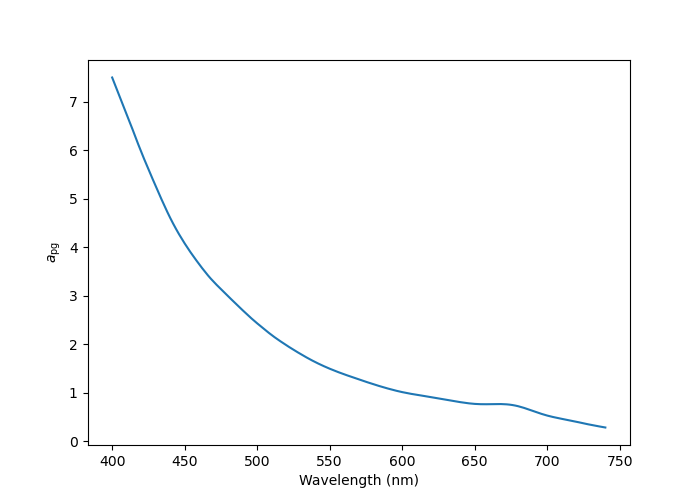

In [79]:
#
fig = plt.figure(figsize=(7,5))

plt.clf()
ax = plt.gca()
ax.plot(wv_nm, mtri_spec[:,0])
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$a_{\rm pg}$')
#ax.legend()
#
plt.show()

## Rebin to L23

In [80]:
mtri_rebinned = []
for spec in mtri_spec.T:
    new_spec, _ = spectra.rebin(wv_nm, spec, np.ones_like(spec), NMF_wave)
    mtri_rebinned.append(new_spec)
mtri_rebinned = np.array(mtri_rebinned)
mtri_rebinned.shape

(5, 59)

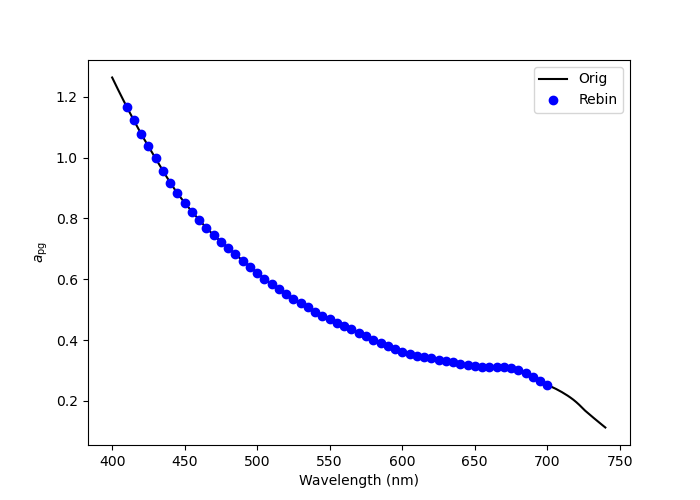

In [83]:
idx = 4
#
fig = plt.figure(figsize=(7,5))

plt.clf()
ax = plt.gca()
ax.plot(wv_nm, mtri_spec[:,idx], 'k-', label='Orig')
ax.plot(NMF_wave, mtri_rebinned[idx], 'bo', label='Rebin')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$a_{\rm pg}$')
ax.legend()
#
plt.show()

# Fit with NMF

## Apply

In [84]:
M.shape

(4, 59)

In [85]:
V = np.ones_like(mtri_rebinned) / 0.05**2
nan = np.isnan(mtri_rebinned)
V[nan] = 0.

In [86]:
mtri_rebinned.shape

(5, 59)

In [94]:
reload(apply)
scale = 1.
NMF_coeff = apply.calc_coeff(M, mtri_rebinned/scale, V)

Working on component:  1
Current Chi2=85.6034, Previous Chi2=1254.0986, Change=93.1741% @ niters=0
Took 0.000 minutes to reach current solution.
Working on component:  2
Current Chi2=82.1796, Previous Chi2=82.8728, Change=0.8365% @ niters=0
Current Chi2=41.0539, Previous Chi2=42.3814, Change=3.1321% @ niters=20
Current Chi2=35.6833, Previous Chi2=35.6902, Change=0.0194% @ niters=40
Took 0.000 minutes to reach current solution.
Working on component:  3
Current Chi2=33.9774, Previous Chi2=34.2241, Change=0.7207% @ niters=0
Current Chi2=20.0863, Previous Chi2=21.1072, Change=4.8368% @ niters=20
Current Chi2=8.0653, Previous Chi2=8.2590, Change=2.3457% @ niters=40
Current Chi2=6.6897, Previous Chi2=6.7093, Change=0.2918% @ niters=60
Current Chi2=6.5255, Previous Chi2=6.5285, Change=0.0456% @ niters=80
Current Chi2=6.4982, Previous Chi2=6.4987, Change=0.0085% @ niters=100
Current Chi2=6.4929, Previous Chi2=6.4930, Change=0.0017% @ niters=120
Took 0.000 minutes to reach current solution.
Wor

In [95]:
NMF_coeff.shape

(4, 5)

In [96]:
NMF_coeff[0]

array([79.37864573, 51.09168174, 54.59541044, 35.89318268, 12.01495934])

## Reconstruct

In [97]:
mtri_recon = np.dot(NMF_coeff.T, M)

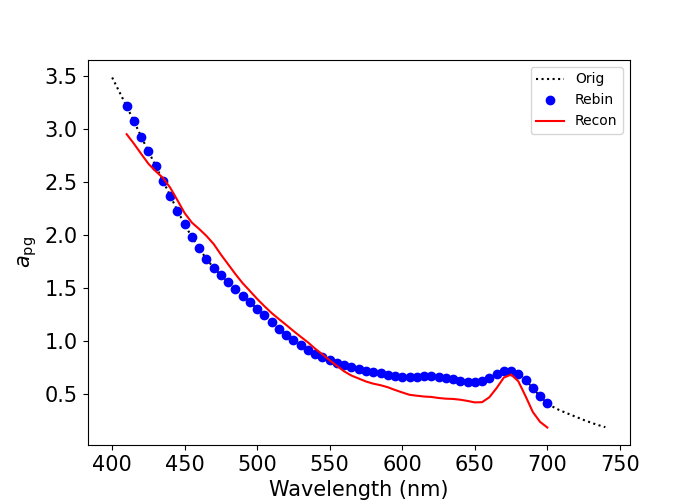

In [103]:
idx = 3
#
fig = plt.figure(figsize=(7,5))

plt.clf()
ax = plt.gca()
ax.plot(wv_nm, mtri_spec[:,idx], 'k:', label='Orig')
ax.plot(NMF_wave, mtri_rebinned[idx], 'bo', label='Rebin')
ax.plot(NMF_wave, mtri_recon[idx]*scale, 'r-', label='Recon')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$a_{\rm pg}$')
plotting.set_fontsize(ax, 15.)
ax.legend()
#
plt.show()